# Model selection: immunogenicity tools: Antibodies
This script aims to perform model selection on immunogenicity prediction tools. Previously different tools and settings have been tested. Comparision to anti-drug antibody (ADA) data using mainly spearman rank correlation, but also Mean Absolute Rank Error (MARE), to the tool scores has resulted in the tools and settings selected for testing in this script. Here the intention is to combine the tools to one predictive model, and perform ridge regression to investigate which tools have the most infulence on the best predicted response. Here ADA data will again be used as the correct/observed response varaible. In difference to previous testing the raw ADA score as well as the raw tool output score will be used in the model selection.\
\
The selected tools and settings for this secondary testing are\
1. netMHC1_EL_pep9:\
netMHCpan for MHC class 1, prediction type EL (elution ligand), peptide length 9, sliding window 5 and the only aviable pre prepare human allel panel with 27 alleles. These are the default settings for this tool.For this prediction 3 types of score are provided: the precentile_EL score, the immunogenicity score and the MHC pre processing score.\
2. netMHC1_pep14:\
This the same settings as scores above, expcet that the peptide length is 14. This are the best scoring settings for this tool\
3. netMHC_II_EL_pep12:\
netMHCpan for MHC class 2, prediciton type EL, peptide length 12, sliding window 5 and human 27 allele panel. For this tool there are two huaman allele panels, either 7 or 27. the human 27 allele panel scored marginally higher with all other combination of settings. Further, for this tool there are 2 different scores: the precentile_EL score and the immunogenicity score. THe MHC pre processing score is not availabe for these settings, only for peptide lengths 13 to 23. This tool and setting combination was the absolute highest scoring one in the initail testing\
4. netMHC_II_EL_pep15:\
This is the same settings as above (3.) but with peptide length 15. Here there are 3 scores: preceintile_EL, immunogenicity and MHC pre processing. This are the default settings for this tool.\
5. biophi_KabKabRelaxed:\
BioPhi OASis predicts how human a peptide is. The numbering scheme is Kabat, CDR definition Kabat and the human percent threshold is set to relaxed (>50%). This is the default setttings for this tool. This tool did not score very high on the spearman rank correlation in the initial testing, however that was calcualted on antibodies only and the main concern here is nanobodies. This tool had the best MARE scores for nanobodies and is therefore included here.\
6. biophi_KabKabStrict\
BioPhi OASis predicts how human a peptide is. The numbering scheme is Kabat, CDR definition Kabat and the human percent threshold is set to strict (>10%). This is the highest scoring settings for this tool.\
7. waltz\
This is a aggregation prediciton tool that has been included because it might improve the immunogenicity predicitons. Default settings are used.\



In [78]:
# load libaries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as sm

In [79]:
# tool outputs
netMHC1_EL_pep9 = pd.read_csv("tool_outputs/AB_netMHC_peplen9_18_03_2026.csv")
netMHC1_EL_pep14 = pd.read_csv("tool_outputs/AB_netMHC_peplen14_18_03_2026.csv")
netMHC_II_EL_pep12 = pd.read_csv("tool_outputs/AB_netMHC_II_peplen12_19_03_2026.csv")
netMHC_II_EL_pep15 = pd.read_csv("tool_outputs/AB_netMHC_II_peplen15_19_03_2026.csv")
biophi_KabKabRelaxed = pd.read_excel("tool_outputs/AB_NRKab_CDRKab_Relaxed_2026-02-25.xlsx")
biophi_KabKabStrict = pd.read_excel("tool_outputs/AB_NrKAb_CDRKab_Strict_2026-02-25.xlsx")
waltz = pd.read_csv("tool_outputs/AB_waltz.txt", sep="\t", header=None, names=["antibody", "waltz_score", "..."])

# load table with the antibody names
seqTable = pd.read_csv("tool_outputs/AB_seqTable_netMHC_II_peplen12.csv")

# load file containing the antibody name and their observed ADA percantage
ADA = pd.read_csv("../../../data/ADA_37AB.txt", sep="\t", header=None, names=["antibody", "ADA_percentage"])

In [80]:
# There are some nanobodies left in the dataset from the inital testing, which are removed here
biophi_KabKabRelaxed = biophi_KabKabRelaxed[((biophi_KabKabRelaxed.Antibody != "Caplacizumab") & 
                                             (biophi_KabKabRelaxed.Antibody != "Vobarilizumab_HC2") & 
                                             (biophi_KabKabRelaxed.Antibody != "Vobarilizumab_HC1"))]

biophi_KabKabStrict = biophi_KabKabStrict[((biophi_KabKabStrict.Antibody != "Caplacizumab") & 
                                           (biophi_KabKabStrict.Antibody != "Vobarilizumab_HC2") & 
                                           (biophi_KabKabStrict.Antibody != "Vobarilizumab_HC1"))]

In [81]:
# Sanity checks

# Check nr of antibodies
if netMHC1_EL_pep14['seq #'].nunique()!=37:
        print( "netMHC1_EL_pep14 does not have 37 antibodies")
if netMHC1_EL_pep9['seq #'].nunique()!=37:
        print( "netMHC1_EL_pep9 does not have 37 antibodies")
if netMHC_II_EL_pep12['seq #'].nunique()!=37:
        print( "netMHC_II_EL_pep12 does not have 37 antibodies")   
if netMHC_II_EL_pep15['seq #'].nunique()!=37:
        print( "netMHC_II_EL_pep15 does not have 37 antibodies")
if biophi_KabKabRelaxed['Antibody'].nunique()!=37:
        print( "biophi_KabKabRelaxed does not have 37 antibodies")
if biophi_KabKabStrict['Antibody'].nunique()!=37:
        print( "biophi_KabKabStrict does not have 37 antibodies")
if waltz['antibody'].nunique()!=37:
        print( "waltz does not have 37 antibodies")


netMHC tools remove the antibody name for analysis, below the antibody name is mapped back

In [82]:
# the netMHC tools do not have the antibody name in the output, only a sequence number
# Here the seq # will be mapped back to the original antibody name using the seqTable
netMHC1_EL_pep9 = netMHC1_EL_pep9.merge(seqTable[['seq #', 'sequence name']], how='left')
netMHC1_EL_pep14 = netMHC1_EL_pep14.merge(seqTable[['seq #', 'sequence name']], how='left')
netMHC_II_EL_pep12 = netMHC_II_EL_pep12.merge(seqTable[['seq #', 'sequence name']], how='left')
netMHC_II_EL_pep15 = netMHC_II_EL_pep15.merge(seqTable[['seq #', 'sequence name']], how='left')


# Compute scores


netMHCpan tools give one score for each peptide - HLA allele combination
Therefore, for each antibody a immunogenicity score will be calculated. The definition of what score is considerd immunogenetic differs for the different tools \
for each netMHC score of interest: precentile score, immunogenicity socre and pre processing score

For the two dataframes netMHC_II_EL_pep15 and netMHC_II_EL_pep12, there are some score values missing (looks like this '-'). 
Below these values have been removed. I have tried to remake the predicitons but I get the same results. I does not seem to be for one speciifc, antibody, HLA allele or something else. The number of missing values are exacly the same when remaking the prediction, this applys to both data frames. Therefore, I belive it is something that for some reason cant be predicted and have simply removed these values. 

In [83]:
# netMHC1_EL_pep9 percentile score

# Immunogenentic is defened as scored <= 1%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 1. 
netMHC1_pep9_percentile = (
    netMHC1_EL_pep9.assign(immunogenic=netMHC1_EL_pep9['netmhcpan_el percentile'] <= 1) # flags rows where percentile is below 1
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_pep9_percentile')
    )


In [84]:
# netMHC1_EL_pep9 Immunogenicity score 

# Immunogenentic is defened as scored larger than 0
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a immunogenicity score above 0. 
netMHC1_pep9_immunogenicity_score = (
    netMHC1_EL_pep9.assign(immunogenic=netMHC1_EL_pep9['immunogenicity score'] > 0) # flags rows where percentile is above 0
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_pep9_immunogenicity_score')
    )


In [85]:
# netMHC1_EL_pep9 Preprocessing score

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMCH1_pep9_preProcess = netMHC1_EL_pep9.groupby('sequence name')['processing total score'].mean().reset_index().rename(columns={'processing total score': 'netMHC1_pep9_preProcess'})

In [86]:
# netMHC1_EL_pep14

# Percentile score

# Immunogenentic is defened as scored <= 1%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 1. 
netMHC1_pep14_percentile = (
    netMHC1_EL_pep14.assign(immunogenic=netMHC1_EL_pep14['netmhcpan_el percentile'] <= 1) # flags rows where percentile is below 1
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_pep14_percentile')
    )

# Immunogenicity score

# Immunogenentic is defened as scored larger than 0
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a immunogenicity score above 0. 
netMHC1_pep14_immunogenicity_score = (
    netMHC1_EL_pep14.assign(immunogenic=netMHC1_EL_pep14['immunogenicity score'] > 0) # flags rows where percentile is above 0
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_pep14_immunogenicity_score')
    )

# Pre-proocessing score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 

netMCH1_pep14_preProcess = netMHC1_EL_pep14.groupby('sequence name')['processing total score'].mean().reset_index().rename(columns={'processing total score': 'netMHC1_pep14_preProcess'})


In [87]:
# netMHC_II_EL_pep12

# Percentile score

# Immunogenentic is defened as scored <= 10%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 10. 
netMHC_II_pep12_percentile = (
    netMHC_II_EL_pep12.assign(immunogenic=netMHC_II_EL_pep12['netmhciipan_el percentile'] <= 10) # flags rows where percentile is below 10
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_II_pep12_percentile')
    )

# Immunogenicity score

# remove the rows with the immunogenicity score of '-' before calculating the mean
netMHC_II_EL_pep12 = netMHC_II_EL_pep12[netMHC_II_EL_pep12['immunogenicity score'] != '-']
# make the column with the immunogenicity score into a numeric column
netMHC_II_EL_pep12['immunogenicity score'] = pd.to_numeric(netMHC_II_EL_pep12['immunogenicity score'])

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody.
netMHC_II_pep12_immunogenicity_score = netMHC_II_EL_pep12.groupby('sequence name')['immunogenicity score'].mean().reset_index().rename(columns={'immunogenicity score':'netMHC_II_pep12_immunogenicity_score'})


# Does not have pre processing score. Due to tool not being able to predict pre processing on peptides shorter than 13 amino acids


In [88]:
# netMHC_II_EL_pep15

# Percentile score

# Immunogenentic is defened as scored <= 10%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 10. 
netMHC_II_pep15_percentile = (
    netMHC_II_EL_pep15.assign(immunogenic=netMHC_II_EL_pep15['netmhciipan_el percentile'] <= 10) # flags rows where percentile is below 10
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_II_pep15_percentile')
    )

# Immunogenicity score

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMHC_II_pep15_immunogenicity_score = netMHC_II_EL_pep15.groupby('sequence name')['immunogenicity score'].mean().reset_index().rename(columns={'immunogenicity score':'netMHC_II_pep15_immunogenicity_score'})

# Pre-proocessing score
# MHC class 2 has 2 preprocessing scores of interest: mhcii-np cleavage probability score and mhcii-np cleavage probability percentile rank

# mhcii-np cleavage probability

# remove the rows with the cleavage probability score of '-' before calculating the mean
netMHC_II_EL_pep15 = netMHC_II_EL_pep15[netMHC_II_EL_pep15['mhcii-np cleavage probability score'] != '-']
# make the column with the cleavage probability score into a numeric column
netMHC_II_EL_pep15['mhcii-np cleavage probability score'] = pd.to_numeric(netMHC_II_EL_pep15['mhcii-np cleavage probability score'])
# Compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMHC_II_pep15_preProcess_cleavProb = netMHC_II_EL_pep15.groupby('sequence name')['mhcii-np cleavage probability score'].mean().reset_index().rename(columns={'processing total score': 'netMHC_II_pep15_preProcess_cleavProb'})

# mhcii-np cleavage probability percentile rank

# remove the rows with the cleavage probability percentile rank of '-' before calculating the mean
netMHC_II_EL_pep15 = netMHC_II_EL_pep15[netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'] != '-']
# make the column with the cleavage probability percentile rank into a numeric column
netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'] = pd.to_numeric(netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'])
# compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMHC_II_pep15_preProcess_cleavProbPercentile = netMHC_II_EL_pep15.groupby('sequence name')['mhcii-np cleavage probability percentile rank'].mean().reset_index().rename(columns={'mhcii-np cleavage probability percentile rank': 'netMHC_II_pep15_preProcess_cleavProbPercentile'})

waltz provides a output that is the positions of amino acid sequences that are considerd aggregation prone. To calculate a quatiable score from that I just take the total ammount of amino acids that are considerd to me aggregation prone. I take total amount of amino acids instead of number of regions because a longer region will be more aggreagtion prone than a shorter region.

In [89]:
# rename the column '...' to nr_aggs
waltz = waltz.rename(columns={'...': 'nr_aggs'})

def sum_ranges(s):
    if pd.isna(s):
        return 0
    total = 0
    for part in s.split(';'):
        start, end = part.strip().split('-')
        total += int(end) - int(start) + 1 # beacuse the values are inclusive
    return total

waltz['nr_aggs'] = waltz['waltz_score'].apply(sum_ranges)

In [90]:
# join all the new dfs with the ADA dataframe. Based on the 'sequence name' in the new dfs and the 'antibody' column in the ADA df
all_predictors_andADA = ADA
all_predictors_andADA = all_predictors_andADA.merge(netMHC1_pep9_percentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC1_pep9_immunogenicity_score, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMCH1_pep9_preProcess, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC1_pep14_percentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC1_pep14_immunogenicity_score, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMCH1_pep14_preProcess, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep12_percentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep12_immunogenicity_score, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep15_percentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep15_immunogenicity_score, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep15_preProcess_cleavProb, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep15_preProcess_cleavProbPercentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])

# Add the OASis Identity score from biophi_KabKabRelaxed to ADA df
all_predictors_andADA = all_predictors_andADA.merge(biophi_KabKabRelaxed[['Antibody', 'OASis Identity']], left_on='antibody', right_on='Antibody', how='left').drop(columns=['Antibody']).rename(columns={'OASis Identity': 'biophi_KabKabRelaxed_score'})
# Add biophi_KabKabStrict
all_predictors_andADA = all_predictors_andADA.merge(biophi_KabKabStrict[['Antibody', 'OASis Identity']], left_on='antibody', right_on='Antibody', how='left').drop(columns=['Antibody']).rename(columns={'OASis Identity': 'biophi_KabKabStrict_score'})

# Add the nr_aggs score from waltz to the ADA df
all_predictors_andADA = all_predictors_andADA.merge(waltz[['antibody', 'nr_aggs']], left_on='antibody', right_on='antibody', how='left').rename(columns={'nr_aggs': 'waltz_nr_aggs'})

In [91]:
# Make all white space and '-' in the column names to '_'
all_predictors_andADA.columns = (
    all_predictors_andADA.columns
    .str.replace(r'[\s\-]+', '_', regex=True)
)

In [92]:
all_predictors_andADA
# export the ADA df to a csv file
all_predictors_andADA.to_csv("ADA_combined_features.csv", index=False)

# Scatterplot ADA against all 15 predictors

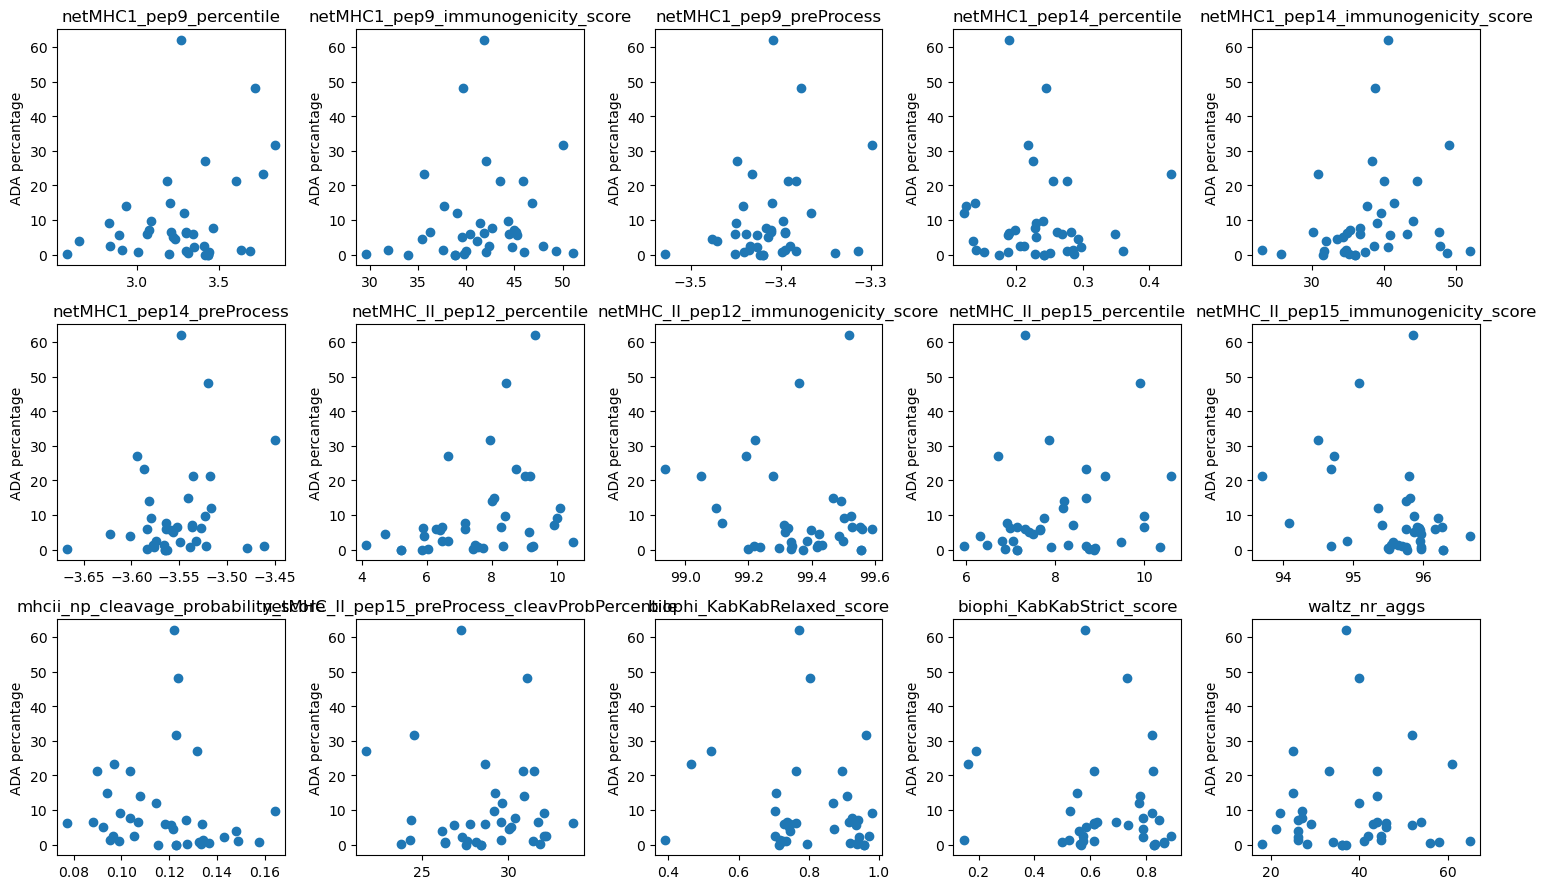

In [93]:
# for loop for all columns, make a scatter plot for each predictor against ADA

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(2, 17):
    ax = axes[i - 2]
    
    y = all_predictors_andADA['ADA_percentage']
    x = all_predictors_andADA.iloc[:, i]
    
    ax.scatter(x, y)
    ax.set_title(all_predictors_andADA.columns[i])
    ax.set_ylabel('ADA percantage')

plt.tight_layout()
plt.show()

# Correlation of potential predictors

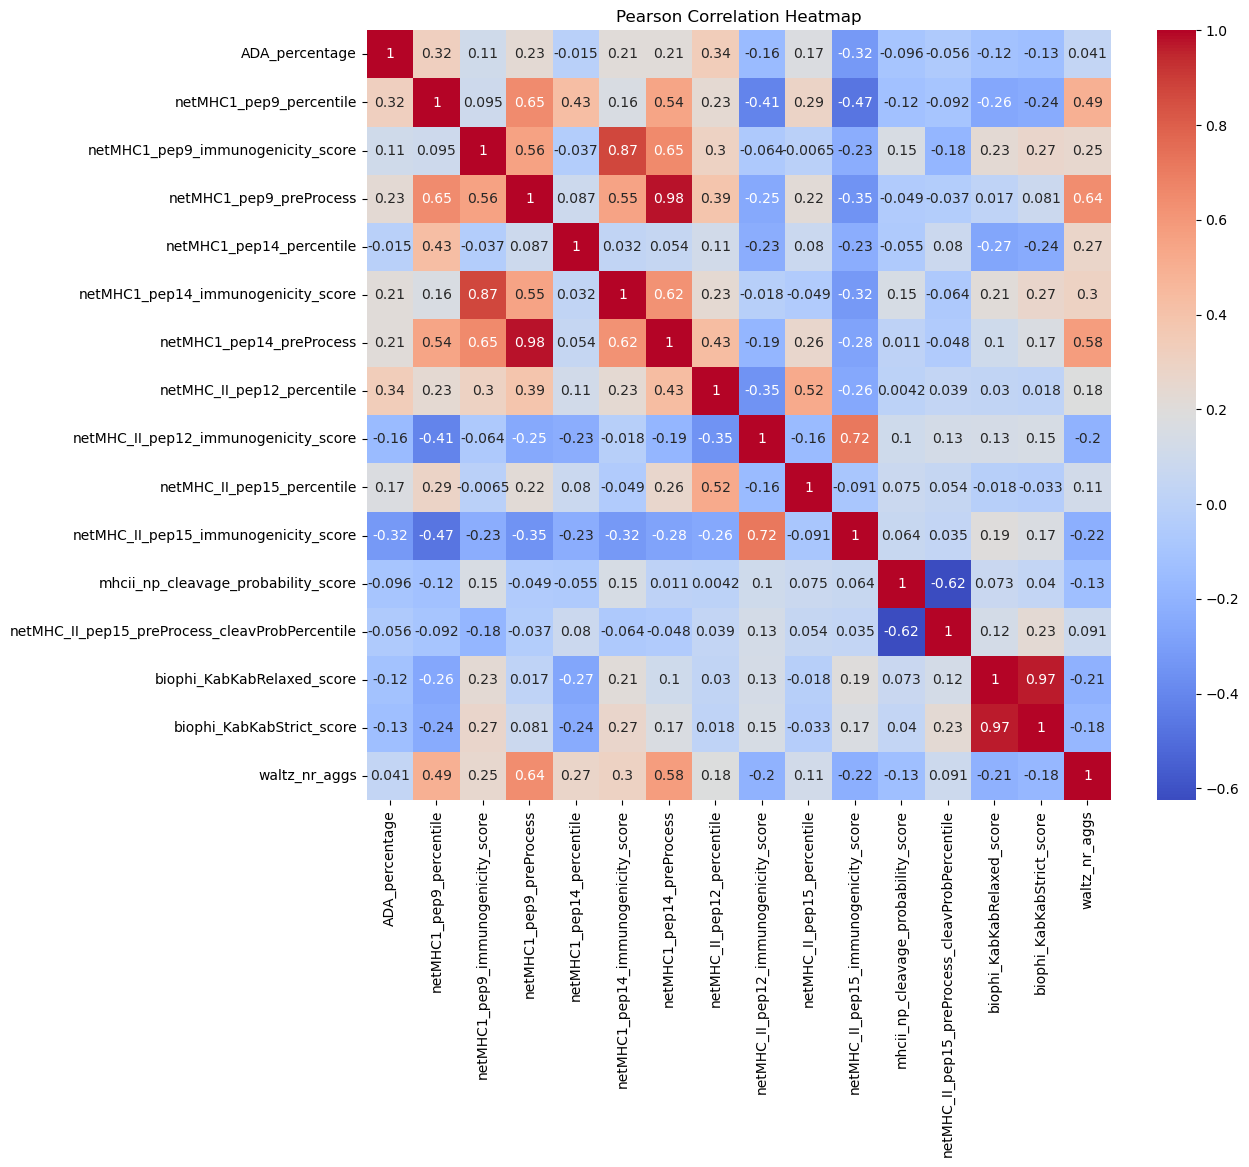

In [94]:
# First create a df without the antibody name and ADA percantage
ADA_corrtest = all_predictors_andADA.drop(columns=['antibody'])
pearson_corr = ADA_corrtest.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()

From the heatmap above we can see a few interesting things.
Firstly, the highest correlation with ADA percantge is netMHC_II_pep15_percentile. Which also was the higest scoring one in the initial testing. So, this is a confirmation of those results. The spearman rank correlation for this combination was ~0.4, here the score is ~0.39, so that also a conformation of the initial results.
Further, there are a few high correlations between tools and settings.
netMCH1 for peptide lengths 9 and 14 correlates very well for the immmunogenicity score and the pre processing score.
Another kind of strong correlation is between netMCH_II for peptide lenghts 12 and 15, which have a high correlation between them for both the percentile score and the immunogenicity score. 

In [95]:
# print the correlation of the ADA percentage column
pearson_corr['ADA_percentage'].sort_values(ascending=False)

ADA_percentage                                    1.000000
netMHC_II_pep12_percentile                        0.335237
netMHC1_pep9_percentile                           0.318140
netMHC1_pep9_preProcess                           0.226079
netMHC1_pep14_immunogenicity_score                0.211283
netMHC1_pep14_preProcess                          0.209518
netMHC_II_pep15_percentile                        0.169848
netMHC1_pep9_immunogenicity_score                 0.105413
waltz_nr_aggs                                     0.040696
netMHC1_pep14_percentile                         -0.015493
netMHC_II_pep15_preProcess_cleavProbPercentile   -0.056372
mhcii_np_cleavage_probability_score              -0.095729
biophi_KabKabRelaxed_score                       -0.116038
biophi_KabKabStrict_score                        -0.130650
netMHC_II_pep12_immunogenicity_score             -0.155379
netMHC_II_pep15_immunogenicity_score             -0.322455
Name: ADA_percentage, dtype: float64

# Lasso regression

In [96]:
# Create feature variables
X = all_predictors_andADA.drop(columns=['antibody', 'ADA_percentage']) # all except the response variable and the antibody names
y = all_predictors_andADA['ADA_percentage'] # the response varibale

model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5,max_iter=10000)  # cross-validation
)

model.fit(X, y)

# coefficients
coef = model.named_steps['lassocv'].coef_

selected_features = X.columns[coef != 0]


In [97]:
selected_features

Index(['netMHC_II_pep12_percentile', 'netMHC_II_pep15_immunogenicity_score'], dtype='object')

# Manual multiple regression


In [98]:
X.iloc[1]

netMHC1_pep9_percentile                            3.433113
netMHC1_pep9_immunogenicity_score                 38.812785
netMHC1_pep9_preProcess                           -3.419684
netMHC1_pep14_percentile                           0.242298
netMHC1_pep14_immunogenicity_score                35.981308
netMHC1_pep14_preProcess                          -3.565096
netMHC_II_pep12_percentile                         5.218855
netMHC_II_pep12_immunogenicity_score              99.557266
netMHC_II_pep15_percentile                         7.149009
netMHC_II_pep15_immunogenicity_score              96.283128
mhcii_np_cleavage_probability_score                0.122660
netMHC_II_pep15_preProcess_cleavProbPercentile    28.419048
biophi_KabKabRelaxed_score                         0.957346
biophi_KabKabStrict_score                          0.829384
waltz_nr_aggs                                     36.000000
Name: 1, dtype: float64

In [102]:

# model 1
# The two features considred best my Lasso
model1 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep12_percentile + netMHC_II_pep15_immunogenicity_score', 
                data=all_predictors_andADA).fit()

# model 2
# The two scores from netMHC II, peptide length 12
model2 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep12_percentile + netMHC_II_pep12_immunogenicity_score', 
                data=all_predictors_andADA).fit()

# model 3
# The four scores from netMCH II, peptide length 15
model3 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC_II_pep15_percentile + netMHC_II_pep15_immunogenicity_score + mhcii_np_cleavage_probability_score + ' \
'netMHC_II_pep15_preProcess_cleavProbPercentile',
                data=all_predictors_andADA).fit()

# model 4
# The three features from netMCH I, peptide length 9
model4 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep9_percentile + netMHC1_pep9_immunogenicity_score + netMHC1_pep9_preProcess' ,
                data=all_predictors_andADA).fit()

# model 5
# The three features from netMCH I, peptide length 14
model5 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep14_percentile + netMHC1_pep14_immunogenicity_score + netMHC1_pep14_preProcess',
                data=all_predictors_andADA).fit()

In [105]:
# Compute and print model fit calculations
print('AIC, BIC, R^2, adjusted R^2')
print("Model1:", model1.aic, model1.bic, model1.rsquared, model1.rsquared_adj)
print("Model2:", model2.aic, model2.bic, model2.rsquared, model2.rsquared_adj)
print("Model3:", model3.aic, model3.bic, model3.rsquared, model3.rsquared_adj)
print("Model4:", model4.aic, model4.bic, model4.rsquared, model4.rsquared_adj)
print("Model5:", model5.aic, model5.bic, model5.rsquared, model5.rsquared_adj)

AIC, BIC, R^2, adjusted R^2
Model1: 303.9130698024834 308.82582828166255 0.1724222140432805 0.12513205484575363
Model2: 306.49856103222623 311.4113195114054 0.11415468539790985 0.06353495313493329
Model3: 308.8721638909357 317.0600946895677 0.15126889022009182 0.048392392064951495
Model4: 308.7733344865337 315.32367912543924 0.10772602948548804 0.028995973263619468
Model5: 310.94007069398486 317.4904153328904 0.055370675691978954 -0.027978970570493367


BIC and adjusted R^2 penalise more for more predictors. Which we can see here, but also not really what im after. AIC also penalises for more parameters, so im mostly looking at R^2.\
Comparing which settings are best for netMHC II, we look at model 2 and model 3. Where model 3 is better (look at R^2). This is with peptide length 15. \
Looking which settings are best for netMHC I, we look at model 4 and model 5. Here model 4 is clearly better. This is with peptide length 9.\
However the combination with netMHC_II_pep12_percentile + netMHC_II_pep15_immunogenicity_score' is still best performing.\
It is unpracticala that its the same tool but with two different settings, so I will first look at immunogenicity score and percetnile score with one settings to investigate which settings is better.

In [106]:
# model 1
# The two features considred best my Lasso
model1 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep12_percentile + netMHC_II_pep15_immunogenicity_score', 
                data=all_predictors_andADA).fit()

# model 6
# Immunogenicity score and percentile score for netMHC peptide length 12
model6 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep12_percentile + netMHC_II_pep12_immunogenicity_score', 
                data=all_predictors_andADA).fit()

# model 7
# # Immunogenicity score and percentile score for netMHC peptide length 15
model7 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep15_percentile + netMHC_II_pep15_immunogenicity_score', 
                data=all_predictors_andADA).fit()


# Print comparative scores
print('AIC, BIC, R^2, adjusted R^2')
print("Model1:", model1.aic, model1.bic, model1.rsquared, model1.rsquared_adj)
print("Model6:", model6.aic, model6.bic, model6.rsquared, model6.rsquared_adj)
print("Model7:", model7.aic, model7.bic, model7.rsquared, model7.rsquared_adj)

AIC, BIC, R^2, adjusted R^2
Model1: 303.9130698024834 308.82582828166255 0.1724222140432805 0.12513205484575363
Model6: 306.49856103222623 311.4113195114054 0.11415468539790985 0.06353495313493329
Model7: 306.0777215267103 310.9904800058895 0.12391105335470942 0.07384882783212132


Between model 6 and model 7, model 7 score better on the R^2. This is also default settings, so I will continue with that. 


In [ ]:
# from the best scoring of the netMHC tools, add them together once and also check with biophi

# model 6
# All for netmhc I, netmch II, biophi and waltz

# model 7
# All for netmch I, netmhc II, biophi 

# model 7
# I need to pick one settings from netmhc I and one for netmhc I and continue with.